In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Download 10 years of AAPL daily data (2015-2024)
data = yf.download('AAPL', start='2015-01-01', end='2025-01-01')

# yfinance returns multi-level columns for single-ticker downloads.
# Flatten to simple column names (Close, High, Low, Open, Volume).
data.columns = data.columns.get_level_values(0)

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.192608,24.659510,23.754472,24.648445,212818400
2015-01-05,23.511057,24.042131,23.325182,23.962469,257142000
2015-01-06,23.513273,23.772171,23.152585,23.575232,263188400
2015-01-07,23.842987,23.942563,23.610642,23.721282,160423600
2015-01-08,24.759081,24.816614,24.053195,24.170475,237458000


In [3]:
# Confirm shape, data types, date range, and check for missing values
# before doing any analysis.
print(data.shape)
print(data.info())
print(data.index.min(), "to", data.index.max())
print(data.isnull().sum())

(2516, 5)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2516 entries, 2015-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2516 non-null   float64
 1   High    2516 non-null   float64
 2   Low     2516 non-null   float64
 3   Open    2516 non-null   float64
 4   Volume  2516 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.9 KB
None
2015-01-02 00:00:00 to 2024-12-31 00:00:00
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


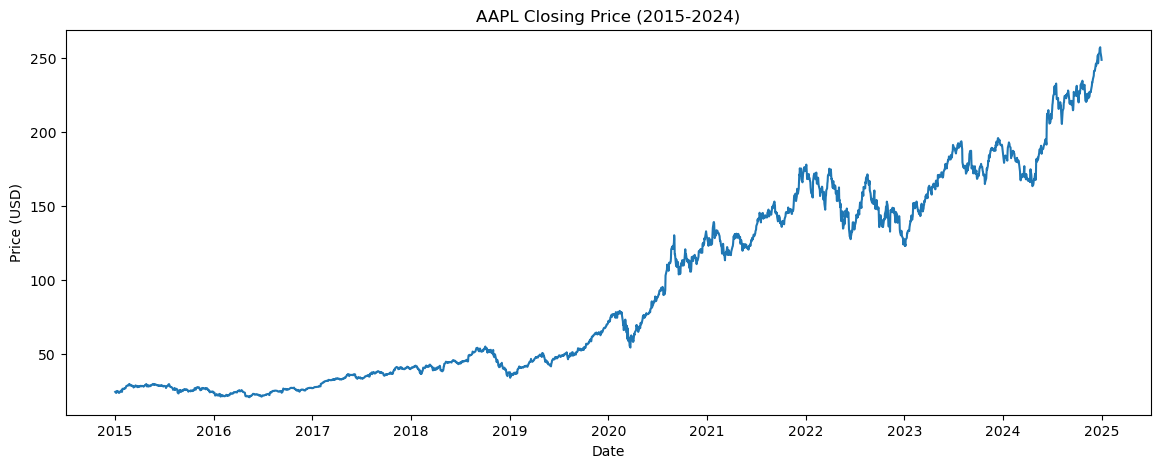

In [4]:
plt.figure(figsize=(14,5))
plt.plot(data.index, data['Close'])
plt.title('AAPL Closing Price (2015-2024)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()

/var/folders/nr/wgjcq78135jf2nktgxv0fppr0000gn/T/ipykernel_23142/3118854339.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = data['Close'].resample('M').mean()


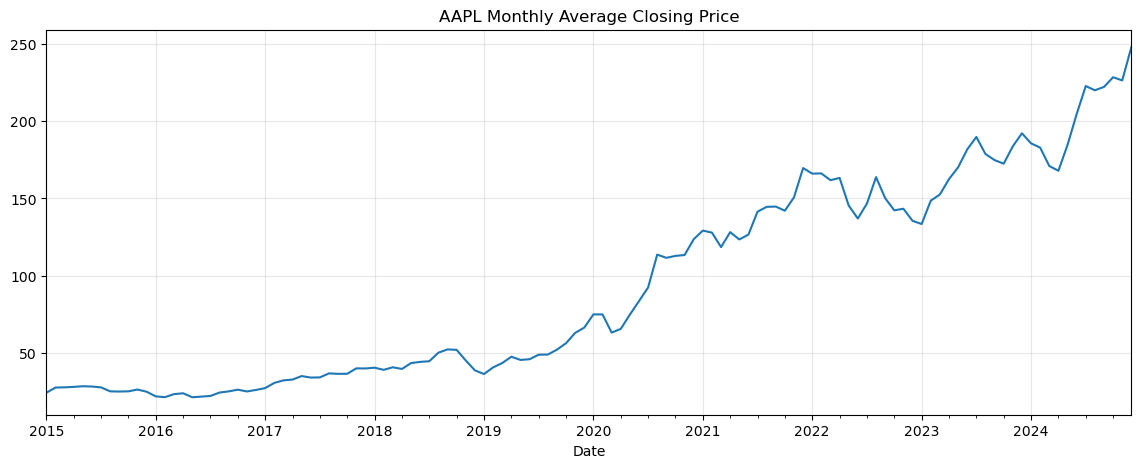

In [10]:
# Daily data is noisy; resampling to monthly averages makes trend
# and seasonality easier to see and model.
monthly = data['Close'].resample('M').mean()

monthly.plot(figsize=(14,5), title='AAPL Monthly Average Closing Price')
plt.grid(True, alpha=0.3)
plt.show()

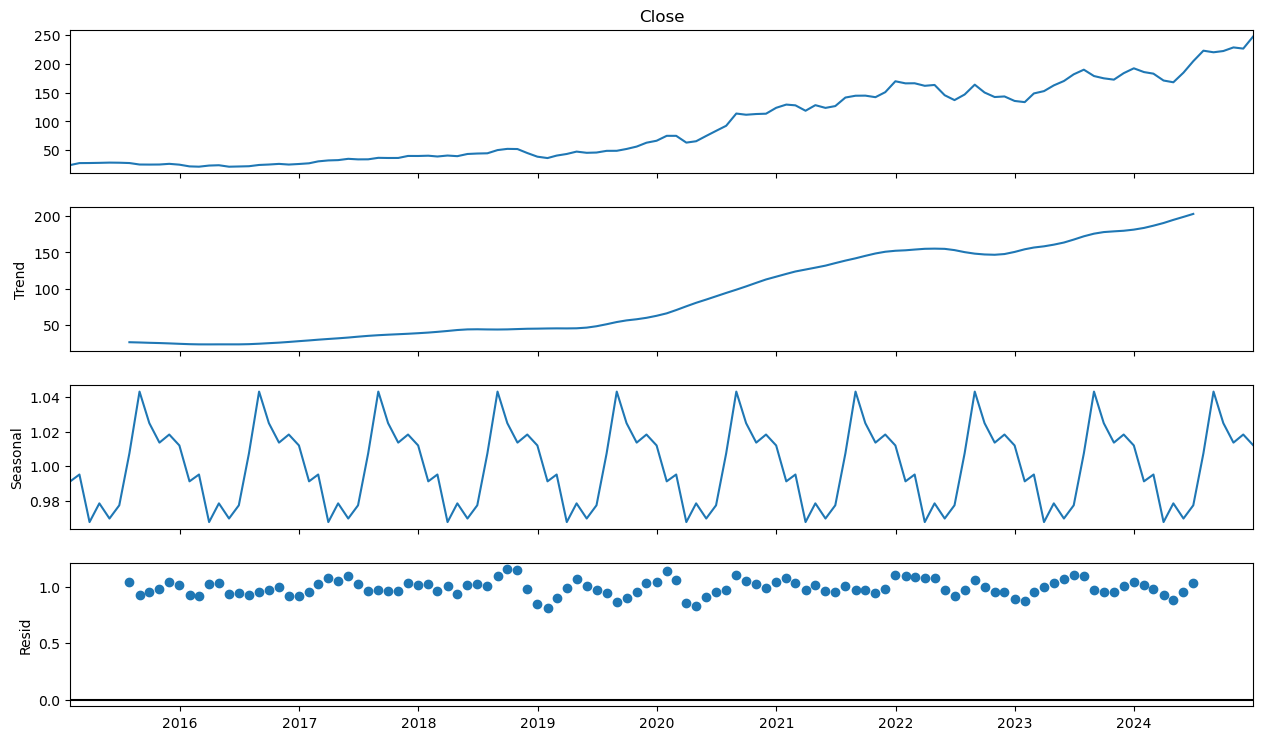

In [11]:
# Multiplicative model chosen because AAPL's price grew ~10x over the
# period (25 -> 250), so seasonal swings scale proportionally with
# price level rather than staying a fixed dollar amount (additive).
decomposition = seasonal_decompose(monthly, model='multiplicative', period=12)

fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.show()

In [12]:
# Test whether the raw monthly series is stationary (required for ARIMA).
result = adfuller(monthly)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
# p-value ~0.9975 -> fails to reject non-stationarity. Confirms the
# clear upward trend visible in thconda install nomkl -ye chart above. Differencing needed.

ADF Statistic: 1.4960720378296526
p-value: 0.9975097216812099


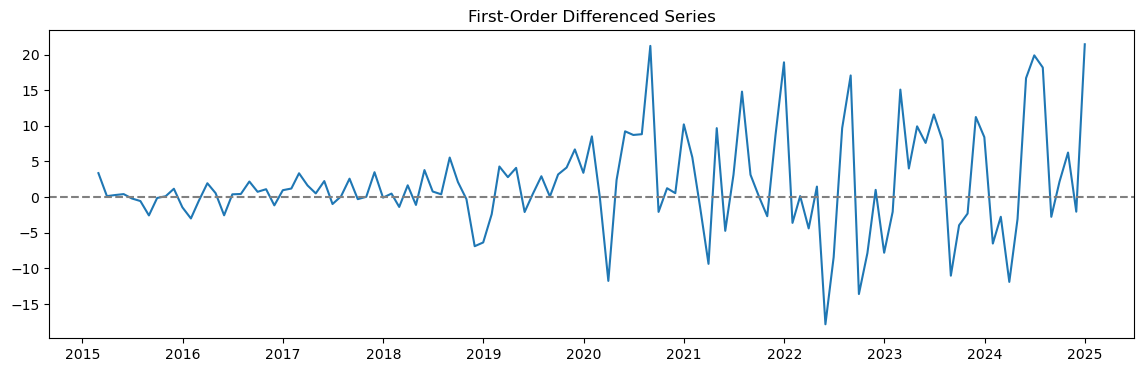

In [13]:
# First-order differencing: model month-over-month CHANGE instead of
# raw price level, to remove the trend and achieve stationarity.
diff = monthly.diff().dropna()

plt.figure(figsize=(14,4))
plt.plot(diff.index, diff)
plt.title('First-Order Differenced Series')
plt.axhline(0, color='gray', linestyle='--')
plt.show()

In [14]:
result_diff = adfuller(diff)
print('ADF Statistic:', result_diff[0])
print('p-value:', result_diff[1])
# p-value ~0.0127 -> stationary. One round of differencing was enough,
# so ARIMA's d parameter = 1.

ADF Statistic: -3.351545611887035
p-value: 0.012725842476416836


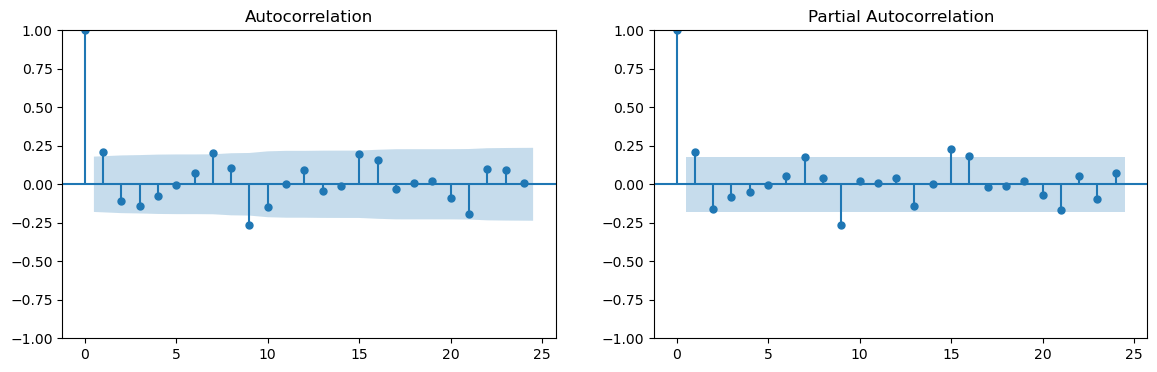

In [15]:
# PACF -> helps identify p (AR term, direct correlation with own past)
# ACF  -> helps identify q (MA term, correlation via past forecast errors)
fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(diff, ax=axes[0], lags=24)
plot_pacf(diff, ax=axes[1], lags=24)
plt.show()
# Both plots show almost no bars significantly outside the confidence
# band beyond lag 0 -> weak autocorrelation in monthly price changes,
# consistent with efficient-market behavior. Suggests low-order p, q.

In [16]:
# Since ACF/PACF gave an ambiguous read, compare a few small candidate
# models directly using AIC (lower = better fit, penalized for complexity).
for order in [(0,1,0), (1,1,0), (0,1,1), (1,1,1), (2,1,2)]:
    m = ARIMA(monthly, order=order).fit()
    print(order, 'AIC:', round(m.aic, 2))
# (0,1,1) had the lowest AIC (~799.7), though all candidates were close
# together -- further evidence of limited learnable structure.

(0, 1, 0) AIC: 808.02
(1, 1, 0) AIC: 801.26
(0, 1, 1) AIC: 799.7
(1, 1, 1) AIC: 801.69
(2, 1, 2) AIC: 805.27


In [17]:
# Hold back the last 12 months (real 2024 data) to honestly evaluate
# forecast accuracy against data the model never saw during fitting.
train = monthly[:-12]
test = monthly[-12:]

eval_model = ARIMA(train, order=(0,1,1)).fit()
eval_forecast = eval_model.forecast(steps=12)

mae = mean_absolute_error(test, eval_forecast)
rmse = np.sqrt(mean_squared_error(test, eval_forecast))
print('ARIMA MAE:', mae)
print('ARIMA RMSE:', rmse)
# ARIMA MAE ~$24.37, RMSE ~$27.57. Forecast came out nearly flat,
# repeating the last known price -- reflecting minimal AR/MA signal
# found in Block 9/10.

ARIMA MAE: 24.370118762488186
ARIMA RMSE: 27.56683899304782


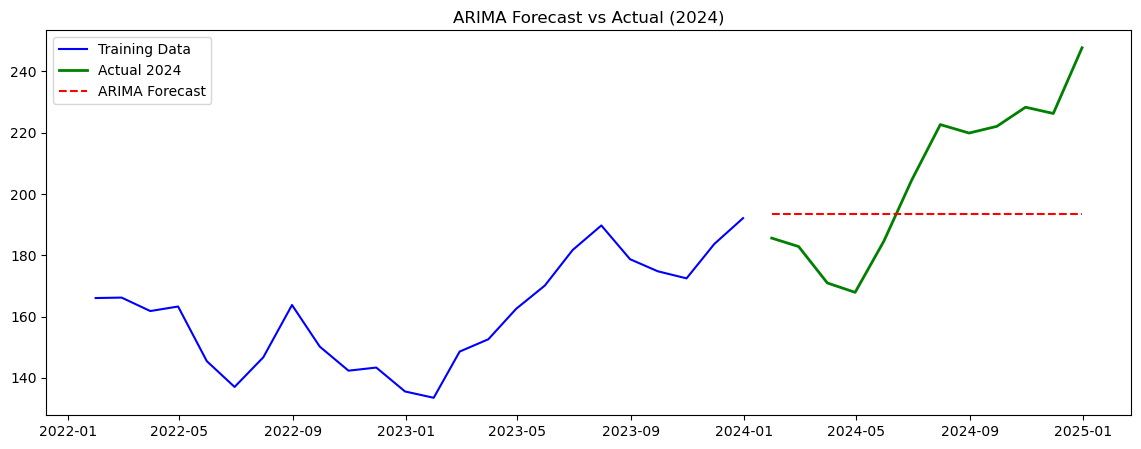

In [18]:
plt.figure(figsize=(14,5))
plt.plot(train.index[-24:], train[-24:], label='Training Data', color='blue')
plt.plot(test.index, test, label='Actual 2024', color='green', linewidth=2)
plt.plot(test.index, eval_forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.legend()
plt.title('ARIMA Forecast vs Actual (2024)')
plt.show()

In [19]:
# Prophet requires a two-column DataFrame named exactly 'ds' (date)
# and 'y' (value). reset_index() converts our date index into a
# normal column so it can be renamed.
prophet_df = monthly.reset_index()
prophet_df.columns = ['ds', 'y']
prophet_df.head()

,ds,y
0,2015-01-31,24.482815
1,2015-02-28,27.848826
2,2015-03-31,27.984926
3,2015-04-30,28.278283
4,2015-05-31,28.700758


In [20]:
prophet_model = Prophet()
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=12, freq='M')
forecast = prophet_model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

01:01:17 - cmdstanpy - INFO - Chain [1] start processing
01:01:18 - cmdstanpy - INFO - Chain [1] done processing
/Users/darkos/opt/anaconda3/lib/python3.9/site-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
120,2025-01-31,223.714274,208.822463,239.551127
121,2025-02-28,223.075248,208.143418,239.534514
122,2025-03-31,221.126687,205.117267,235.714982
123,2025-04-30,224.285822,208.896358,240.099821
124,2025-05-31,226.938874,209.343081,241.694001
125,2025-06-30,231.331147,216.095215,247.037306
126,2025-07-31,238.076961,221.494266,254.334778
127,2025-08-31,242.377315,226.232466,256.795861
128,2025-09-30,241.168126,224.495558,255.967043
129,2025-10-31,241.711588,226.395906,257.355117


In [21]:
train_p = prophet_df[:-12]
test_p = prophet_df[-12:]

eval_prophet = Prophet()
eval_prophet.fit(train_p)

future_eval = eval_prophet.make_future_dataframe(periods=12, freq='M')
forecast_eval = eval_prophet.predict(future_eval)
prophet_pred = forecast_eval['yhat'][-12:].values

mae_p = mean_absolute_error(test_p['y'], prophet_pred)
rmse_p = np.sqrt(mean_squared_error(test_p['y'], prophet_pred))
print('Prophet MAE:', mae_p)
print('Prophet RMSE:', rmse_p)
# Prophet MAE ~$15.76, RMSE ~$17.85 -- roughly 35% lower error than
# ARIMA on both metrics.

01:01:27 - cmdstanpy - INFO - Chain [1] start processing
01:01:27 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: 16.13401296818117
Prophet RMSE: 18.237947961464872


/Users/darkos/opt/anaconda3/lib/python3.9/site-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


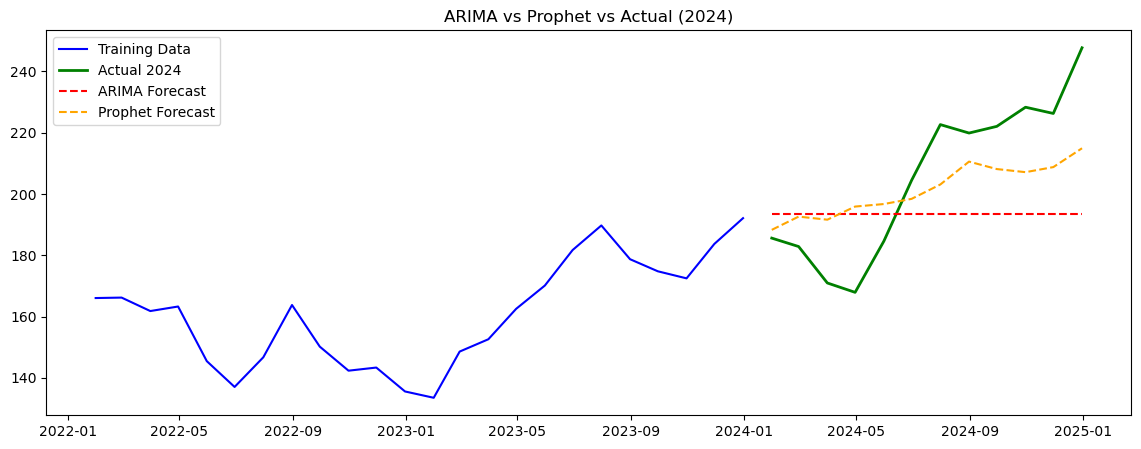

In [22]:
plt.figure(figsize=(14,5))
plt.plot(train.index[-24:], train[-24:], label='Training Data', color='blue')
plt.plot(test.index, test, label='Actual 2024', color='green', linewidth=2)
plt.plot(test.index, eval_forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.plot(test_p['ds'], prophet_pred, label='Prophet Forecast', color='orange', linestyle='--')
plt.legend()
plt.title('ARIMA vs Prophet vs Actual (2024)')
plt.show()

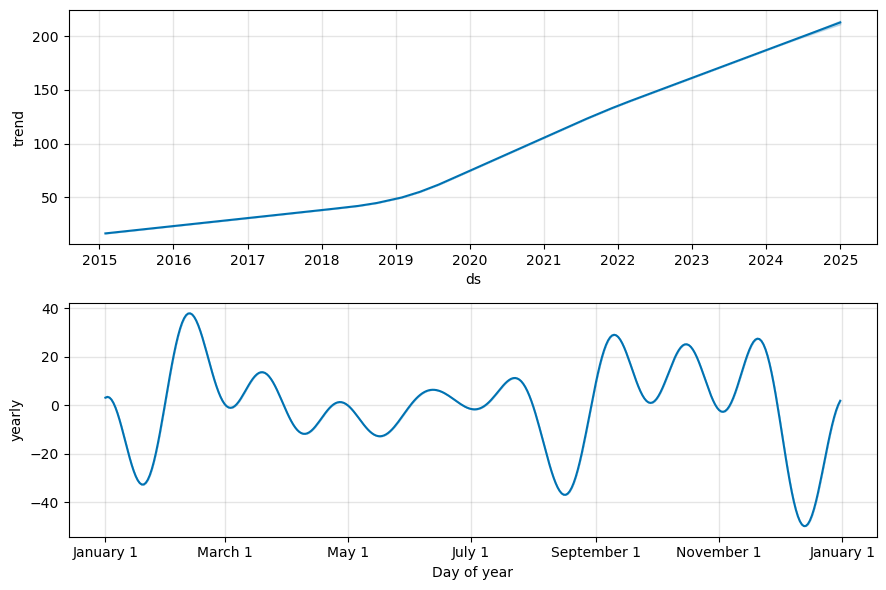

In [23]:
# Shows WHY Prophet outperformed ARIMA: an explicit trend curve and a
# repeating yearly seasonal wave (Q4 peak, tied to iPhone launches +
# holiday sales) -- structure ARIMA had no mechanism to capture.
fig2 = eval_prophet.plot_components(forecast_eval)
plt.show()